## Business Problem

In the highly competitive mobile phone market, it is difficult for new companies to decide the appropriate price of their products. Incorrect pricing can lead to losses or reduced competitiveness.

The objective of this project is to build a machine learning model that can predict the price range of mobile phones based on their features such as RAM, battery power, internal memory, and connectivity options. This will help the company make better pricing decisions and compete effectively in the market.

In [94]:
# import Libraries  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [95]:
df = pd.read_csv('cellphone.csv')

In [96]:
# All columns show
pd.set_option("display.max_columns",None)

In [97]:
# Back to default
pd.reset_option("display.max_columns")

## Basic Check

In [98]:
# First 5 rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [99]:
# Last 5 rows
df.tail() 

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [100]:
# Column names
df.columns         

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [101]:
# Rows, Columns
df.shape

(2000, 21)

In [102]:
# Data types + null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [103]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [104]:
df.duplicated().sum()

np.int64(0)

## EDA

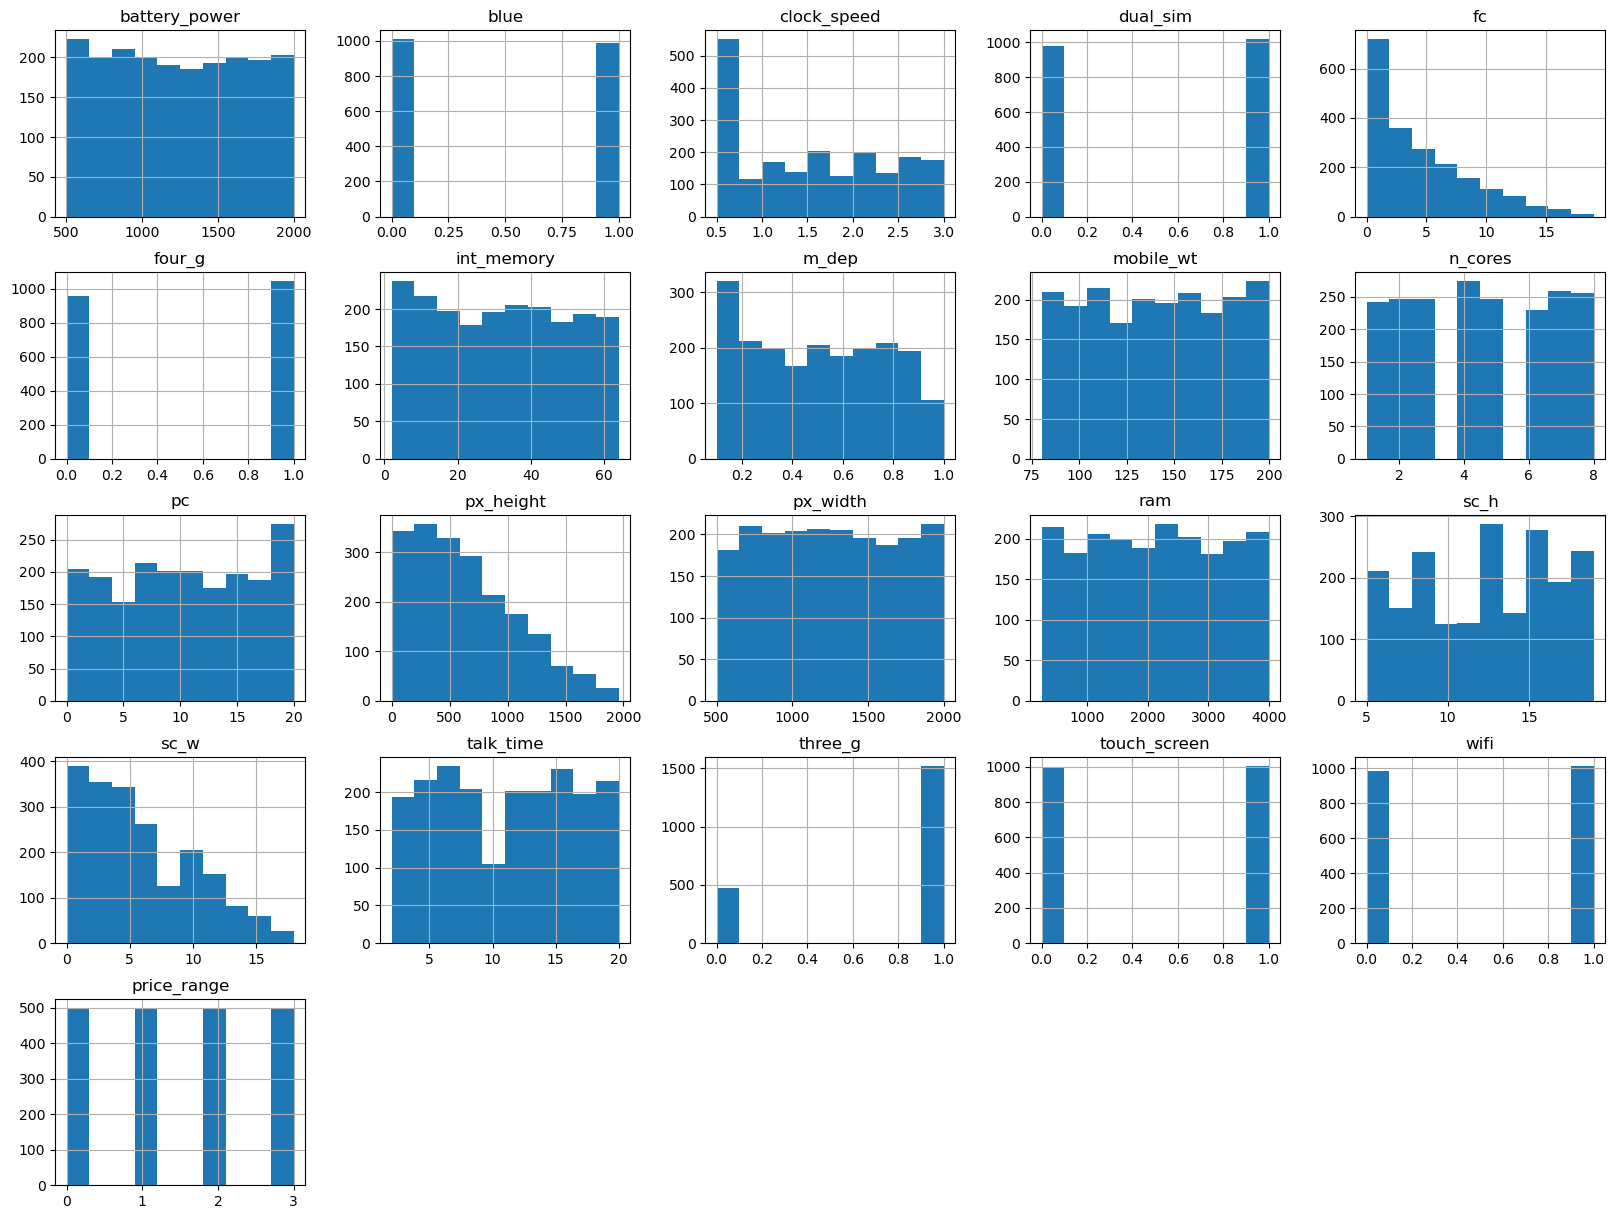

In [105]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(20,15))
plt.show()

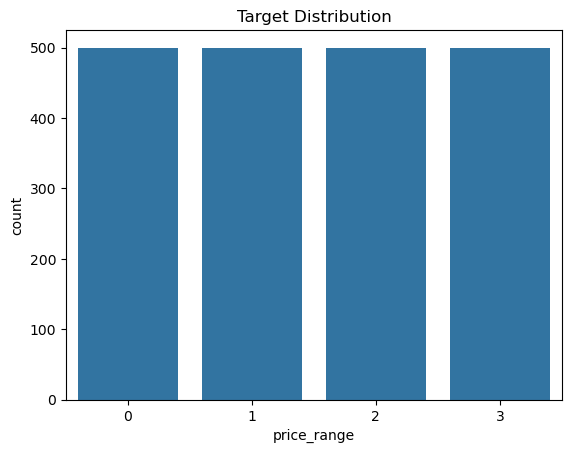

In [106]:
sns.countplot(x=df.price_range)
plt.title("Target Distribution")
plt.show()

## Feature Engineering
1. Data Preprocessing

* Checking Null Value

In [15]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

* We will handling the outliers only for Countinous features.

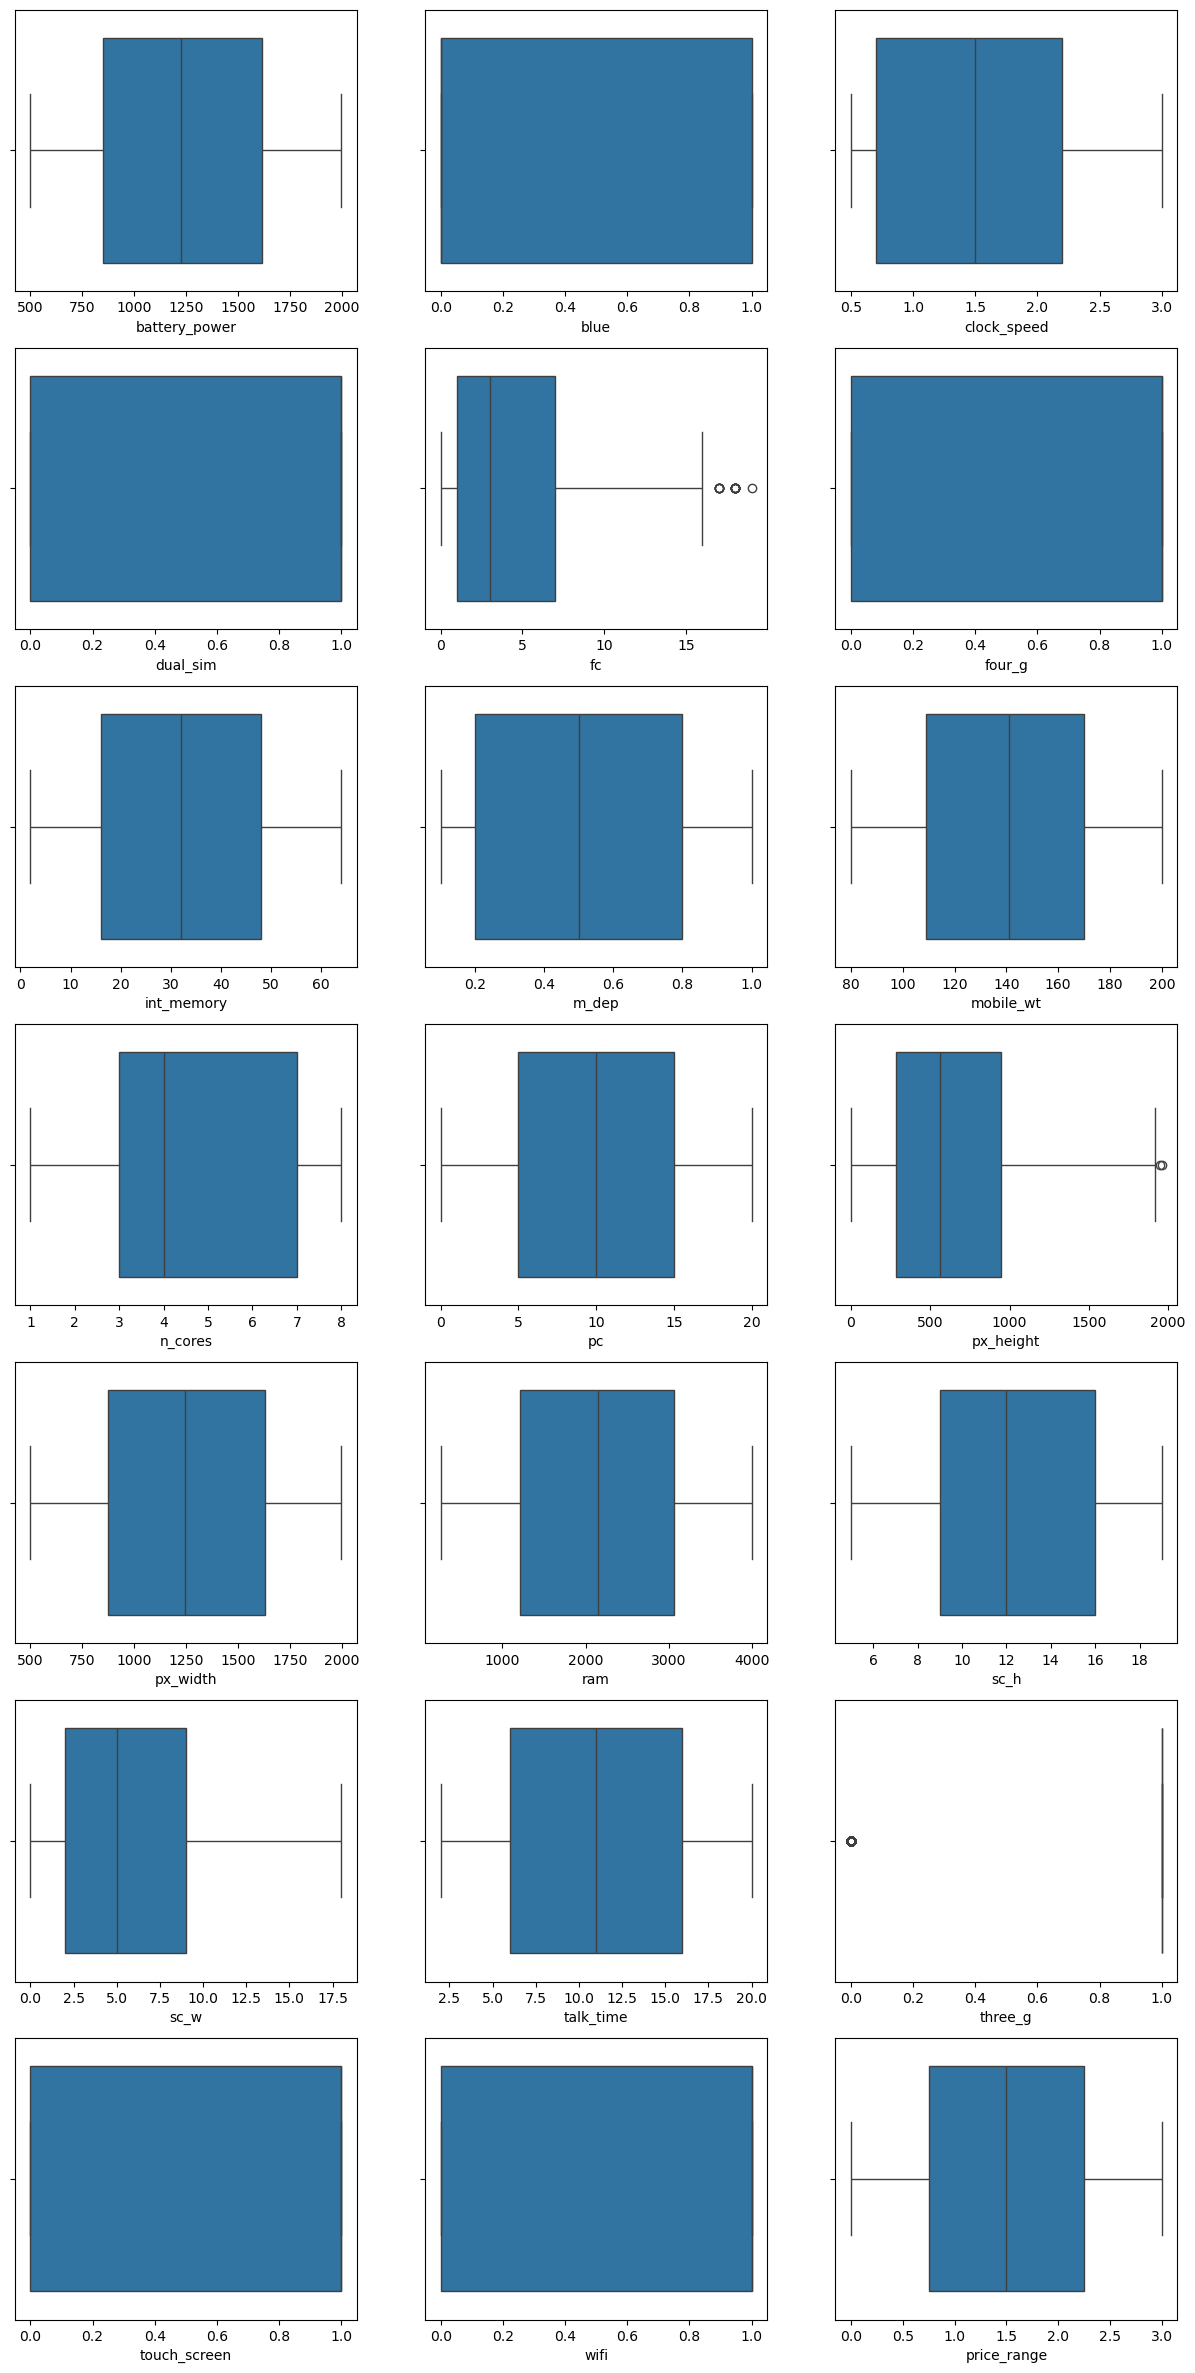

In [107]:
plot = 1
plt.figure(figsize=(15,30))
for i in df:
    if plot <= 21:
        plt.subplot(7,3,plot)
        sns.boxplot(x=df[i])
        plt.xlabel(i)
    plot = plot + 1    
plt.show()    

#### Fc
- We will replacing outliers for fc using IQR

In [108]:
Q1 = df['fc'].quantile(0.25)
Q3 = df['fc'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['fc'] >= lower) & (df['fc'] <= upper)]

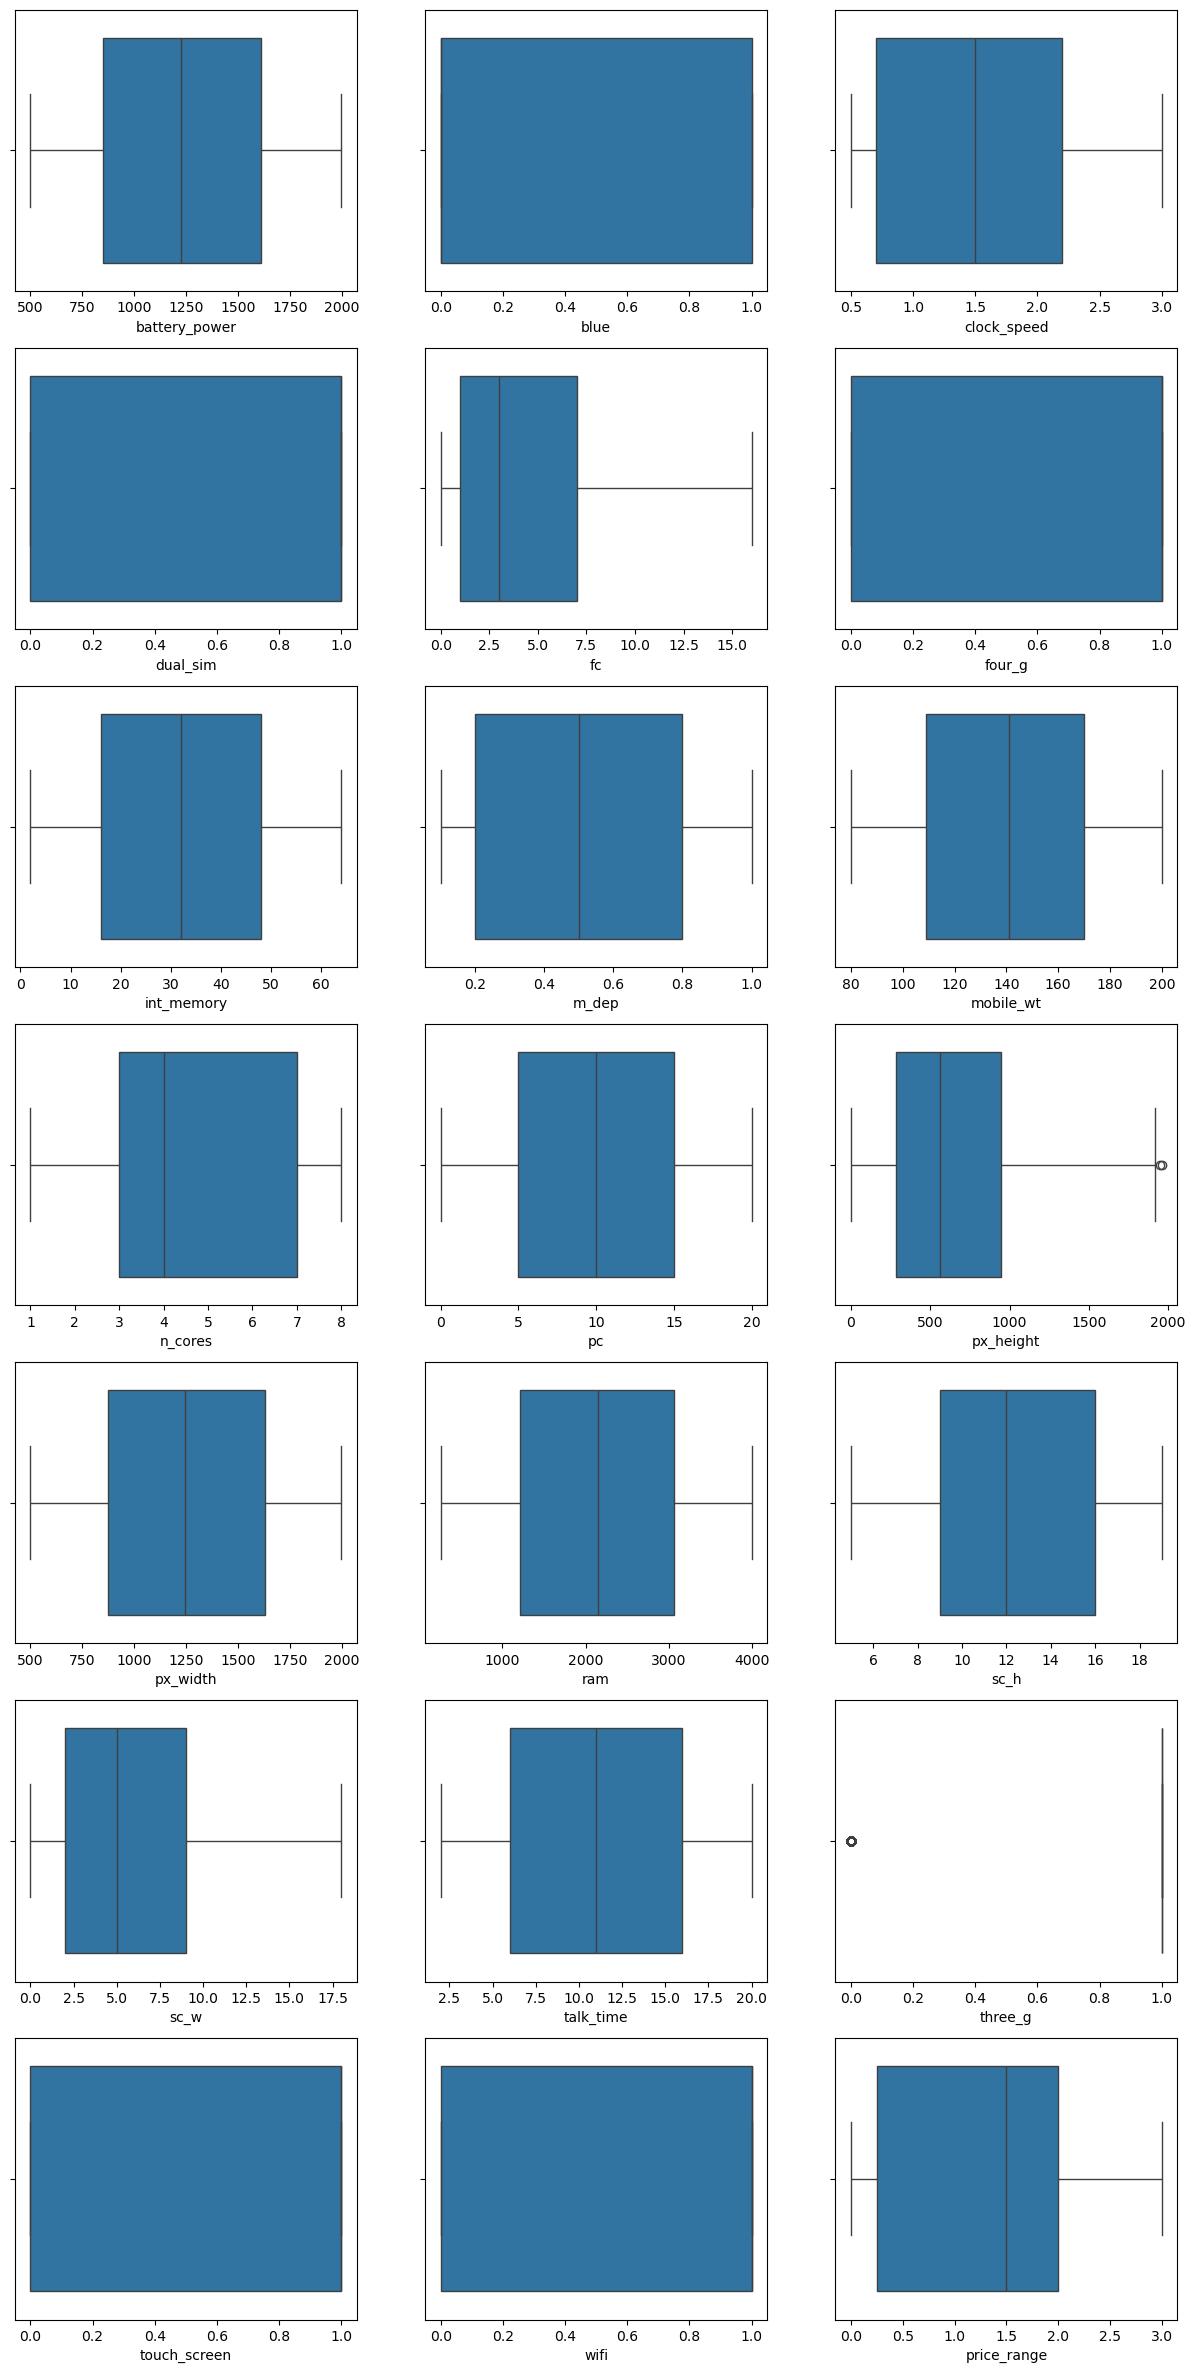

In [109]:
plot = 1
plt.figure(figsize=(15,30))
for i in df:
    if plot <= 21:
        plt.subplot(7,3,plot)
        sns.boxplot(x=df[i])
        plt.xlabel(i)
    plot = plot + 1    
plt.show()    

* Now we have handled our outliers.

2. Feature Selection

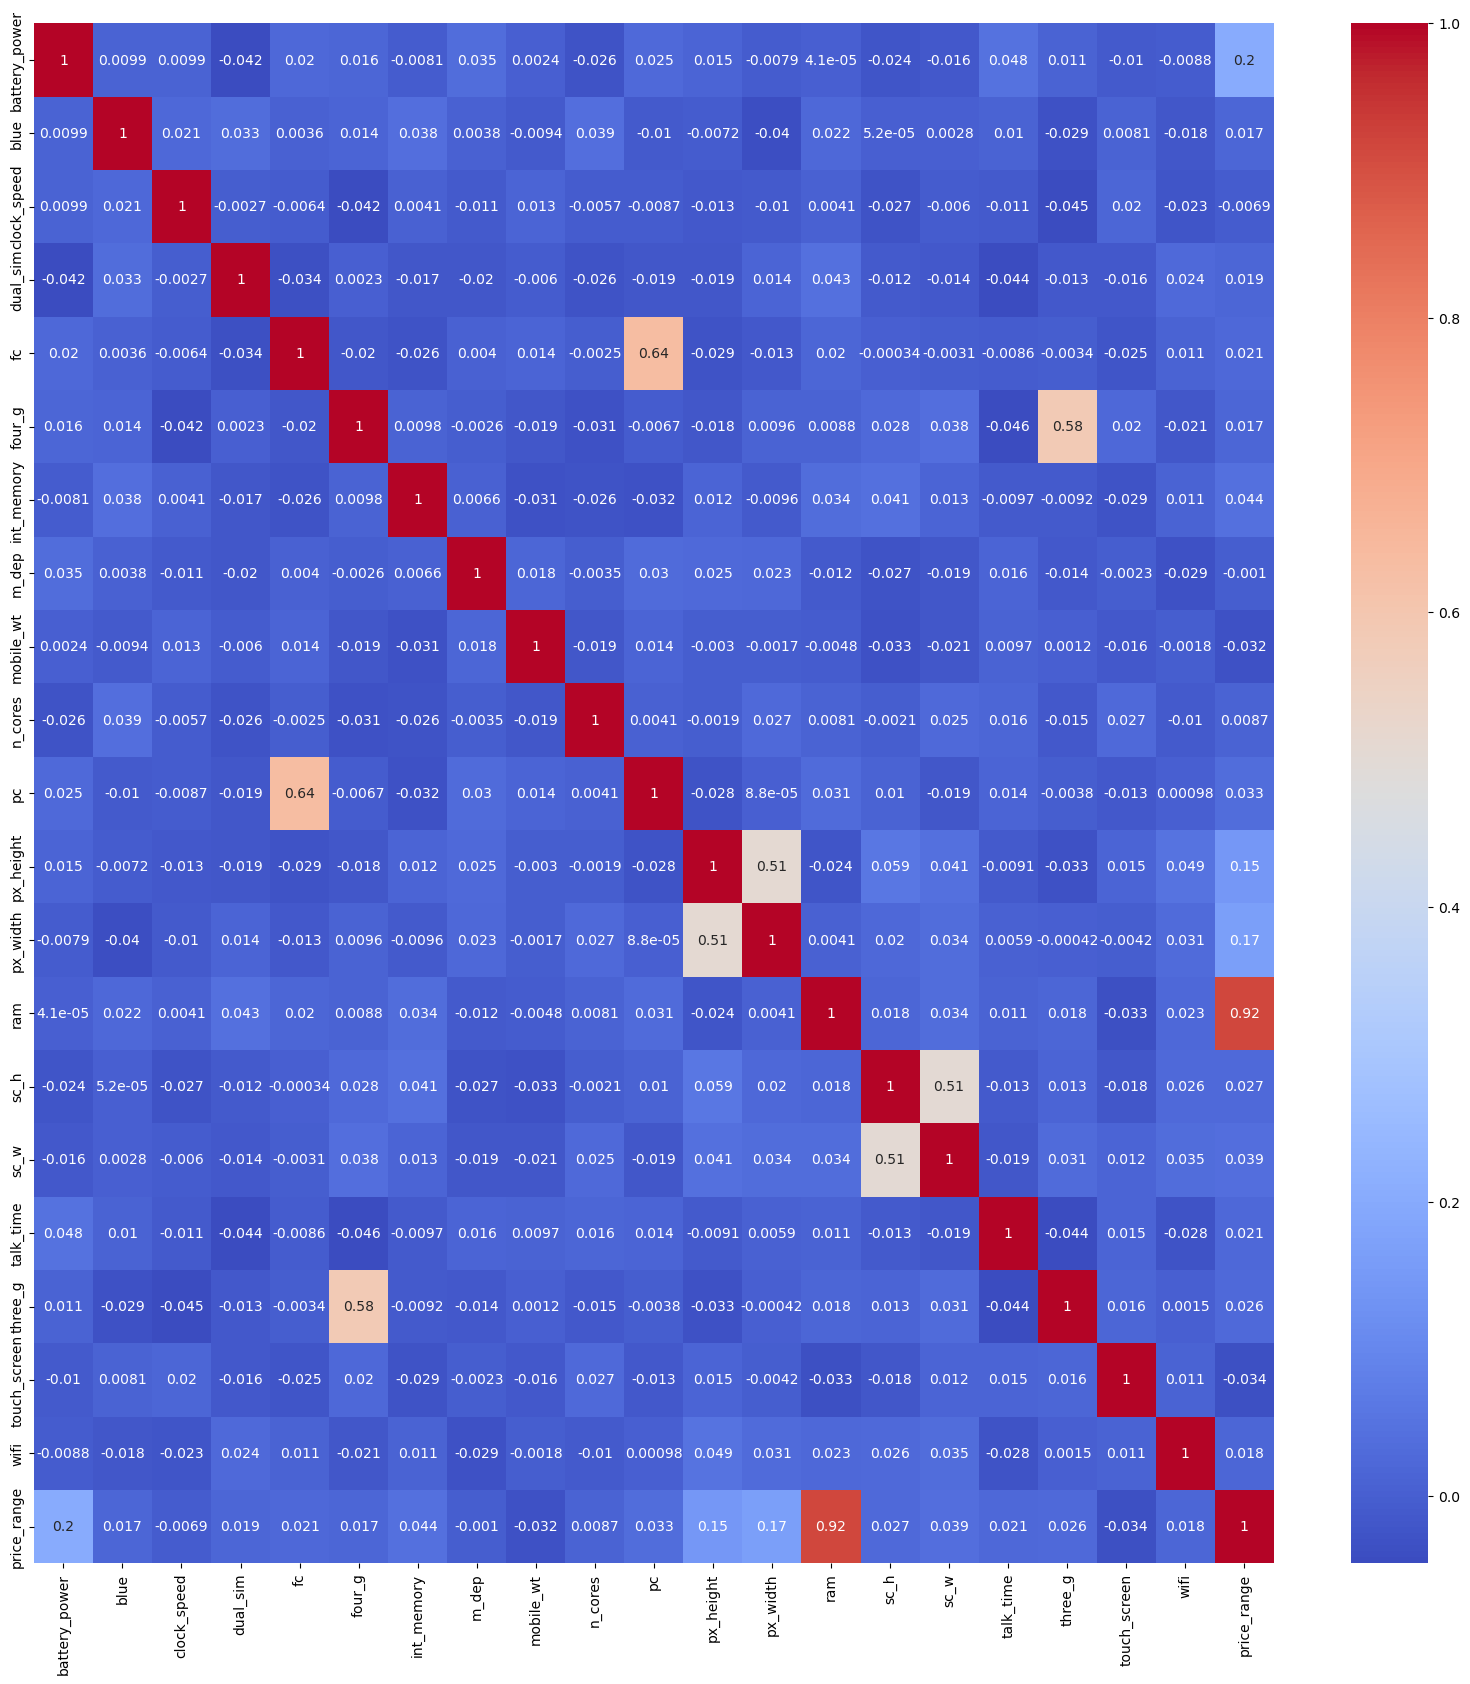

In [110]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

* The RAM has a strong impact on price range.

## Model Selection

#### Defining X and Y
- Spliting data into Train and Test

In [111]:
x = df.drop('price_range', axis=1)
y = df['price_range']

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=33)

In [114]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale

StandardScaler()

In [115]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

## Data Balancing

In [116]:
from collections import Counter
Counter(y_train)

Counter({1: 411, 2: 406, 3: 386, 0: 382})

* The dataset is fairly balanced, so no resampling techniques were applied.

## Cross Validation

In [117]:
from sklearn.model_selection import cross_val_score

In [118]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=1)

In [119]:
scores = cross_val_score(model,x,y,cv=3,scoring='accuracy')
print("Cross-Validation Scores:",scores)
print("Cross validation Mean Score:",scores.mean())
print("Std :",scores.std())

Cross-Validation Scores: [0.63993949 0.63237519 0.64848485]
Cross validation Mean Score: 0.6402665077400327
Std : 0.006580804860129066


## Model Creation

###  Logistic Regression

In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
model = LogisticRegression(random_state=1)

In [122]:
model.fit(x_train,y_train)

LogisticRegression(random_state=1)

In [123]:
y_pred = model.predict(x_test)

### Model Evaluation

In [34]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [91]:
print("Logistic")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

Logistic
Accuracy score: 0.9571788413098237
Precision score: 0.9574765367671231
Recall score: 0.9571788413098237
F1 score: 0.9568193437490526
Confusion matrix:
[[114   0   0   0]
 [  4  74   6   0]
 [  0   3  86   2]
 [  0   0   2 106]]


* Since the problem is multiclass classification, weighted averaging was used for precision, recall, and F1-score.

### RandomForest Classifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
rf = RandomForestClassifier(random_state=1)
rf

RandomForestClassifier(random_state=1)

In [79]:
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=1)

In [80]:
y_pred = rf.predict(x_test)

### Model Evaluation

In [81]:
print("RandomForest Classifier")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

RandomForest Classifier
Accuracy score: 0.8992443324937027
Precision score: 0.9007460231011869
Recall score: 0.8992443324937027
F1 score: 0.8996807592291832
Confusion matrix:
[[105   9   0   0]
 [  6  73   5   0]
 [  0   8  77   6]
 [  0   0   6 102]]


### Hyperparameter Tuning of RandomForestClassifier

In [97]:
params = {
    "n_estimators":[100,150,200],
    "criterion":["entropy","gini"],
    "min_samples_leaf":[1,2,4,6],
    "max_depth":[1,2,4,5,None],
    "min_samples_split":[1,2,4,6],
    "max_features":[0.5,5]}

In [98]:
from sklearn.model_selection import GridSearchCV

In [99]:
random = GridSearchCV(estimator=RandomForestClassifier(),param_grid=params,
                            n_jobs=1,
                            cv=3,verbose=3,scoring='accuracy')

In [121]:
random.fit(x_train,y_train)

Fitting 3 folds for each of 960 candidates, totalling 2880 fits
[CV 1/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=100;, score=nan total time=   0.0s
[CV 2/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=100;, score=nan total time=   0.0s
[CV 3/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=100;, score=nan total time=   0.0s
[CV 1/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=150;, score=nan total time=   0.0s
[CV 2/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=150;, score=nan total time=   0.0s
[CV 3/3] END criterion=entropy, max_depth=1, max_features=0.5, min_samples_leaf=1, min_samples_split=1, n_estimators=150;, score=nan total time=   0.0s
[CV 1/3] END criterion=e

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [1, 2, 4, 5, None],
                         'max_features': [0.5, 5],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [1, 2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='accuracy', verbose=3)

In [122]:
random.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'max_features': 0.5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 150}

In [123]:
rf1 = RandomForestClassifier(n_estimators=200,min_samples_split=2,min_samples_leaf=1,
                             max_depth=None,max_features=0.5,criterion='entropy')

In [124]:
rf1.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', max_features=0.5, n_estimators=200)

In [125]:
y_pred = rf1.predict(x_test)

### Model Evaluation

In [126]:
print("Hyperparameter Tuning of RandomForestClassifier")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

Hyperparameter Tuning of RandomForestClassifier
Accuracy score: 0.9168765743073047
Precision score: 0.9170910931412979
Recall score: 0.9168765743073047
F1 score: 0.9169720430796597
Confusion matrix:
[[108   6   0   0]
 [  5  74   5   0]
 [  0   5  80   6]
 [  0   0   6 102]]


### Decision Tree

In [100]:
from sklearn.tree import DecisionTreeClassifier

In [101]:
dt = DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [102]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [103]:
y_pred = dt.predict(x_test)

### Model Evaluation

In [127]:
print("Decisiontree")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

Decisiontree
Accuracy score: 0.9168765743073047
Precision score: 0.9170910931412979
Recall score: 0.9168765743073047
F1 score: 0.9169720430796597
Confusion matrix:
[[108   6   0   0]
 [  5  74   5   0]
 [  0   5  80   6]
 [  0   0   6 102]]


### Hyperparameter Tuning of DecisionTreeClassifier

In [105]:
params = {
    "criterion":["entropy","gini"],
    "splitter":["best","random"],
    "max_depth":[1,2,3,4,6],
    "min_samples_leaf":[1,4,3,6,8],
    "min_samples_split":[1,4,6,8,12]
}

In [106]:
from sklearn.model_selection import GridSearchCV

In [107]:
dt1 = GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=params,cv=3,
             n_jobs=1,verbose=3,scoring="accuracy")

In [ ]:
dt1.fit(x_train,y_train)

In [109]:
dt1.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'min_samples_leaf': 4,
 'min_samples_split': 6,
 'splitter': 'best'}

In [112]:
dt2 = DecisionTreeClassifier(criterion='entropy',max_depth=6,min_samples_leaf=4,
                             min_samples_split=6,splitter='best')

In [113]:
dt2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=4,
                       min_samples_split=6)

In [114]:
y_pred = dt2.predict(x_test)

### Model Evaluation

In [115]:
print("Hyperparameter Tuning of DecisionTreeClassifier")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

Hyperparameter Tuning of DecisionTreeClassifier
Accuracy score: 0.836272040302267
Precision score: 0.8401027799077546
Recall score: 0.836272040302267
F1 score: 0.8376709494698679
Confusion matrix:
[[103  11   0   0]
 [  8  67   9   0]
 [  0  14  68   9]
 [  0   0  14  94]]


### KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
knn = KNeighborsClassifier(n_neighbors=20)
knn

KNeighborsClassifier(n_neighbors=20)

In [59]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=20)

In [60]:
y_pred = knn.predict(x_test)

### Model Evaluation

In [61]:
print("KNN")
print("Accuracy score:", accuracy_score(y_test,y_pred))
print("Precision score:", precision_score(y_test,y_pred,average='weighted'))
print("Recall score:", recall_score(y_test,y_pred,average='weighted'))
print("F1 score:", f1_score(y_test,y_pred,average='weighted'))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))

KNN
Accuracy score: 0.6272040302267002
Precision score: 0.6524376793750034
Recall score: 0.6272040302267002
F1 score: 0.6355633466521488
Confusion matrix:
[[82 30  2  0]
 [27 44 12  1]
 [ 1 25 52 13]
 [ 0  5 32 71]]


## Model Comparison Report

In [124]:
model_comparison = {
    "Model": ["Logistic Regression", "Random Forest" , "Decision Tree", "KNN"],
    "Accuracy": [0.957, 0.899, 0.916, 0.627]   
}

import pandas as pd
df_model = pd.DataFrame(model_comparison)
df_model

,Model,Accuracy
0,Logistic Regression,0.957
1,Random Forest,0.899
2,Decision Tree,0.916
3,KNN,0.627


Among all the models, Logistic Regression achieved the highest accuracy of 95.7%, making it the best performing model for this dataset. Decision Tree and Random Forest also performed well with accuracies of 91.6% and 89.9% respectively. However, KNN showed significantly lower performance with an accuracy of 62.7%.

Therefore, Logistic Regression is selected as the final model for predicting the price range of mobile phones.

Although Random Forest provides feature importance insights, Logistic Regression is selected as the final model due to its highest accuracy.

## Feature Importance

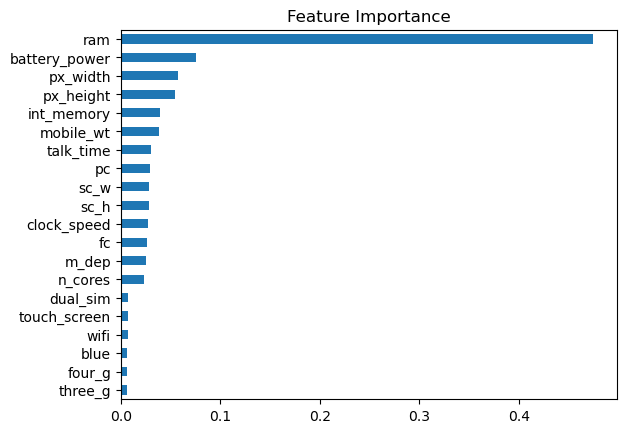

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = x.columns

feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure()
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

From the feature importance graph, it is clear that RAM has the highest impact on mobile price prediction. Features like battery power and pixel resolution also play a significant role, whereas features like Bluetooth and WiFi have relatively less impact.

## Business Insight

The model helps the company understand which features influence the price range of mobile phones. For example, mobiles with higher RAM and better battery power fall into higher price categories. This insight allows the company to design products according to target customers, such as budget-friendly phones or premium smartphones. It also helps in making strategic decisions related to pricing and product development.

## Challenges Faced

During the project, several challenges were encountered. The dataset contained outliers, which were handled using the IQR method. Feature scaling was required to improve model performance, especially for distance-based algorithms like KNN. Selecting the best model among multiple algorithms was also challenging, which was addressed using model comparison and evaluation metrics.

## Final Conclusion

In this project, multiple machine learning models were applied to predict the price range of mobile phones based on their features. Among all the models, Logistic Regression performed the best with the highest accuracy of 95.7%. The model can effectively help businesses in pricing strategy and product design. Overall, the project demonstrates how machine learning can be used to solve real-world business problems.